# Testing MPNN Models trained with spice and SPICE Datasets

## spice Dataset

In [1]:
from torch.utils.data import random_split
import numpy as np
import importlib
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("dataset_loader.log"),
        logging.StreamHandler()
    ]
)

In [2]:
from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelEncoder import ModelEncoder

spice_dataset_encoder = ModelEncoder(collapse=True)

# Load the spice files
spice_sdf_path = "./data/SPICE/SPICE_batch_0_2.sdf"
spice_json_labels = "./data/SPICE/SPICE_batch_0_2_gaff2.json"

# Initialize dataset
spice_dataset = GNNdataset(spice_sdf_path, 
                              spice_json_labels, 
                              directed_graph=True, 
                              labeled=True,
                              encoder=spice_dataset_encoder)

[2025-04-22 20:34:50,981] INFO - Enabling RDKit 2024.03.5 jupyter extensions
[2025-04-22 20:34:51,548] INFO - NumExpr defaulting to 10 threads.
[2025-04-22 20:34:51,863] INFO - Loaded atom type labels for 15545 molecules from ./data/SPICE/SPICE_batch_0_2_gaff2.json
[20:34:54] Both bonds on one end of an atropisomer are on the same side - atoms are: 37 38
[2025-04-22 20:34:54,505] INFO - Loaded 15545 total molecules | 15545 labeled | 0 skipped due to atom/label mismatch.
[2025-04-22 20:34:54,996] INFO - Attempting to process 15545 *labeled* mols from sdf dataset to graphs.
[2025-04-22 20:45:50,926] INFO - Processed 15545 molecular graphs from 15545 molecules.


FULL DATASET (encoded):


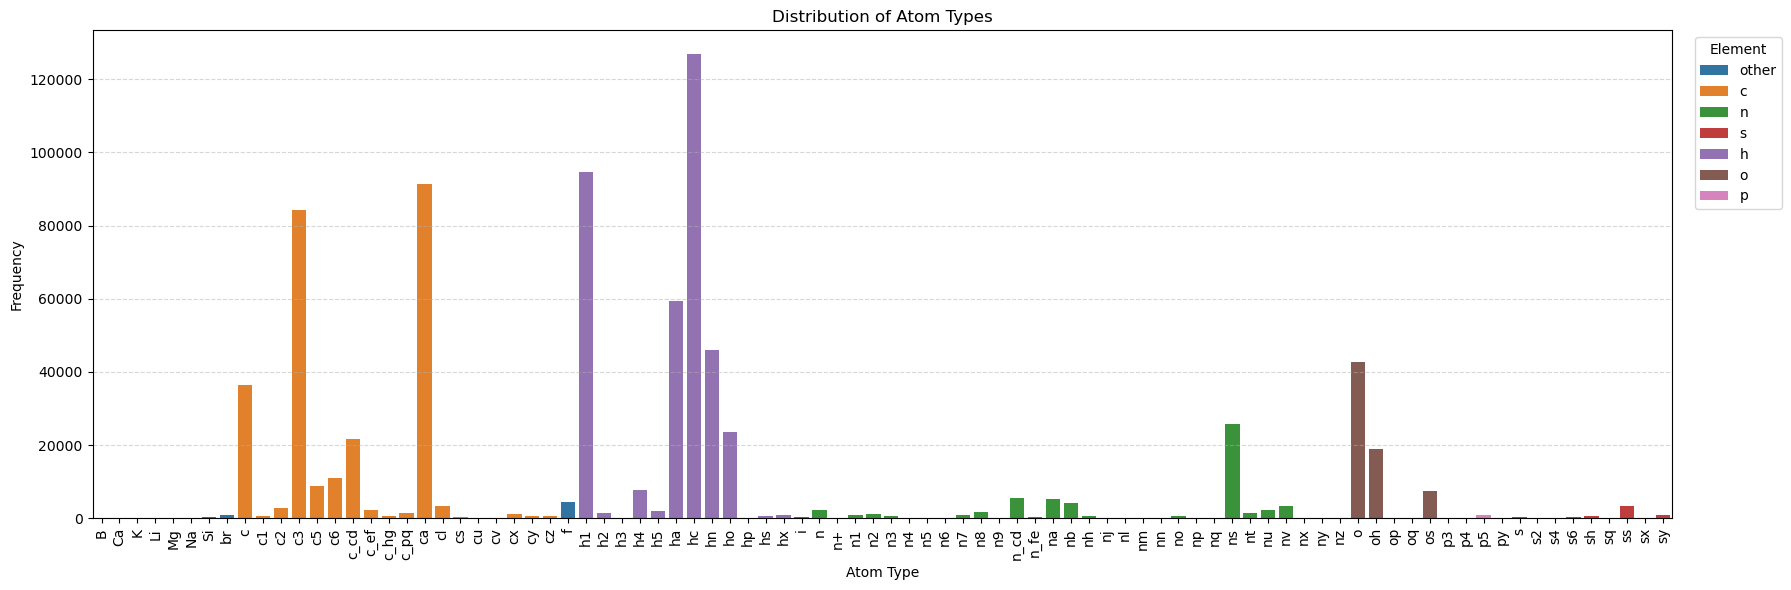

In [3]:
from atoMLtype.analysis.accuracy_counts import plot_atom_distribution

# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(spice_dataset))
test_size = len(spice_dataset) - train_size
train_dataset, test_dataset = random_split(spice_dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(spice_dataset_encoder.inverse_transform(spice_dataset.encoded_labels)))

AtomBondMPNN - Number of parameters: 10995810
--- Fold 1/5 ---


Epoch 1: Train Loss = 1.2169, Val Loss = 0.0471
Epoch 6: Train Loss = 0.0105, Val Loss = 0.0188
Epoch 11: Train Loss = 0.0058, Val Loss = 0.0083
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.0058, Val Loss = 0.0049
Epoch 6: Train Loss = 0.0044, Val Loss = 0.0038
Epoch 11: Train Loss = 0.0064, Val Loss = 0.0045
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0053, Val Loss = 0.0093
Epoch 6: Train Loss = 0.0038, Val Loss = 0.0045
Epoch 11: Train Loss = 0.0023, Val Loss = 0.0050
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0057, Val Loss = 0.0102
Epoch 6: Train Loss = 0.0052, Val Loss = 0.0060
Epoch 11: Train Loss = 0.0023, Val Loss = 0.0024
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0024, Val Loss = 0.0017
Epoch 6: Train Loss = 0.0105, Val Loss = 0.0239
Epoch 11: Train Loss = 0.0028, Val Loss = 0.0032


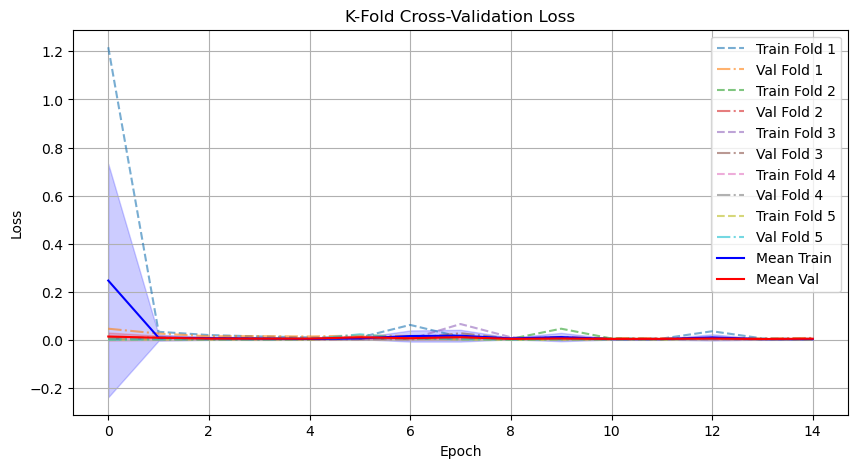

{'train_loss': [[1.216911525801906,
   0.03428759481193211,
   0.020741068635004297,
   0.015006435146045122,
   0.011217447447977685,
   0.010493085490243304,
   0.06288610033547745,
   0.012566588133654839,
   0.007916160685328936,
   0.007354046781052753,
   0.0058230258077532,
   0.0061088590314683075,
   0.03650212141553035,
   0.006877007708719148,
   0.0051053101762639904],
  [0.005789188771964503,
   0.00515605012975397,
   0.007617804612937689,
   0.007181422258153222,
   0.00494790874893549,
   0.004397627979172831,
   0.006003554051294774,
   0.005384510684114795,
   0.004961199647992924,
   0.047122835825462735,
   0.00637524571366451,
   0.004363622165582078,
   0.0048537132392388466,
   0.0038154883657994607,
   0.0036355297193307757],
  [0.005335277439770734,
   0.004445734198598753,
   0.004483714122079357,
   0.0035364163776270283,
   0.0028699792932641837,
   0.003818109595084932,
   0.0038549881339663204,
   0.06651758722008837,
   0.011609471095817921,
   0.00411290

In [4]:
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN
from atoMLtype.models.ModelTrainer import GNNTrainer

AtomMPNN_spice = AtomBondMPNN(atom_input_dim=train_dataset[0].x.shape[1], 
                                      bond_input_dim=train_dataset[0].edge_attr.shape[1], 
                                      hidden_dim=512,
                                      encoder=spice_dataset_encoder, 
                                      num_layers=10,
                                      use_attention=True)

trainer_AtomMPNN_spice = GNNTrainer(AtomMPNN_spice, 
                                   dataset=train_dataset, 
                                   batch_size=32, learning_rate=0.001,
                                   epochs=15, 
                                   k_folds=5, 
                                   random_seed=21)

trainer_AtomMPNN_spice.train(verbose=True)



In [5]:
from atoMLtype.models.ModelEngine import ModelEngine

modelEngine_spice = ModelEngine(model=AtomMPNN_spice, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

spice_record = modelEngine_spice.predict(analysis=True)


In [6]:
spice_record.summary()

Prediction Summary: 77239/77329 correct (99.88% accuracy)
True label distribution: Counter({'hc': 12612, 'ca': 9351, 'h1': 9275, 'c3': 8325, 'ha': 6081, 'hn': 4670, 'o': 4297, 'c': 3644, 'ns': 2548, 'ho': 2517, 'c_cd': 2088, 'oh': 1993, 'c6': 1070, 'c5': 881, 'os': 746, 'h4': 744, 'na': 545, 'n_cd': 531, 'nb': 444, 'f': 380, 'nv': 379, 'cl': 340, 'ss': 306, 'c2': 286, 'c_ef': 253, 'nu': 241, 'n': 225, 'c_pq': 195, 'h5': 182, 'hx': 164, 'n8': 142, 'nt': 140, 'h2': 136, 'n2': 130, 'cx': 113, 'n7': 104, 'br': 99, 'sy': 85, 'p5': 82, 'n1': 79, 'cz': 74, 'c_hg': 70, 'cy': 69, 'hs': 68, 'sh': 67, 'nh': 65, 'c1': 62, 'n3': 62, 'no': 56, 'n_fe': 55, 'Si': 42, 's6': 41, 's': 35, 'cs': 32, 'B': 17, 'i': 15, 'n4': 14, 'nz': 11, 's4': 8, 'hp': 6, 'op': 5, 'h3': 5, 'py': 4, 'oq': 3, 'ny': 3, 'p3': 2, 'nx': 2, 'nj': 2, 'sx': 2, 'np': 1, 'Li': 1, 'K': 1, 'n9': 1, 'Na': 1, 'n6': 1, 'cu': 1, 'cv': 1, 'nq': 1})
Pred label distribution: Counter({'hc': 12612, 'ca': 9355, 'h1': 9271, 'c3': 8319, 'ha': 6083

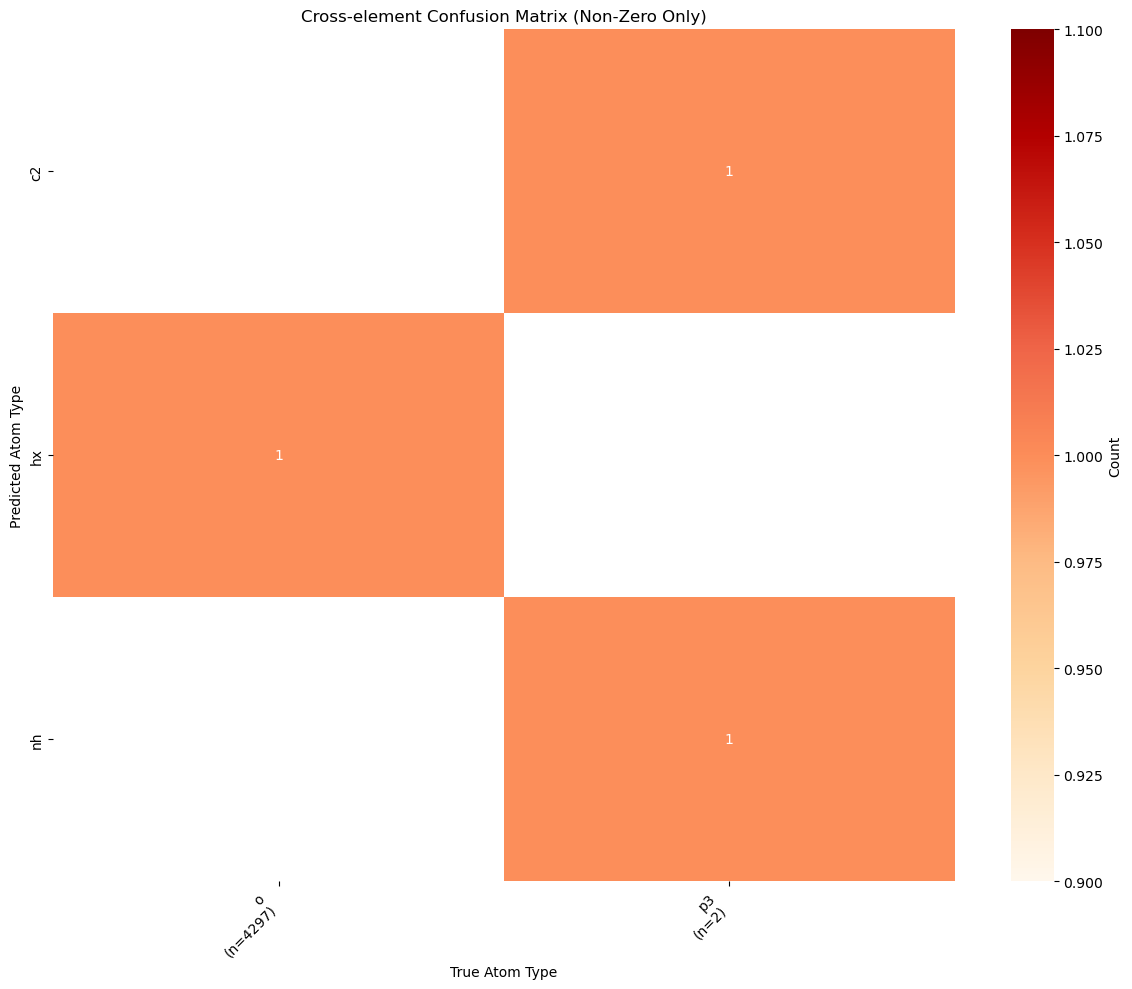

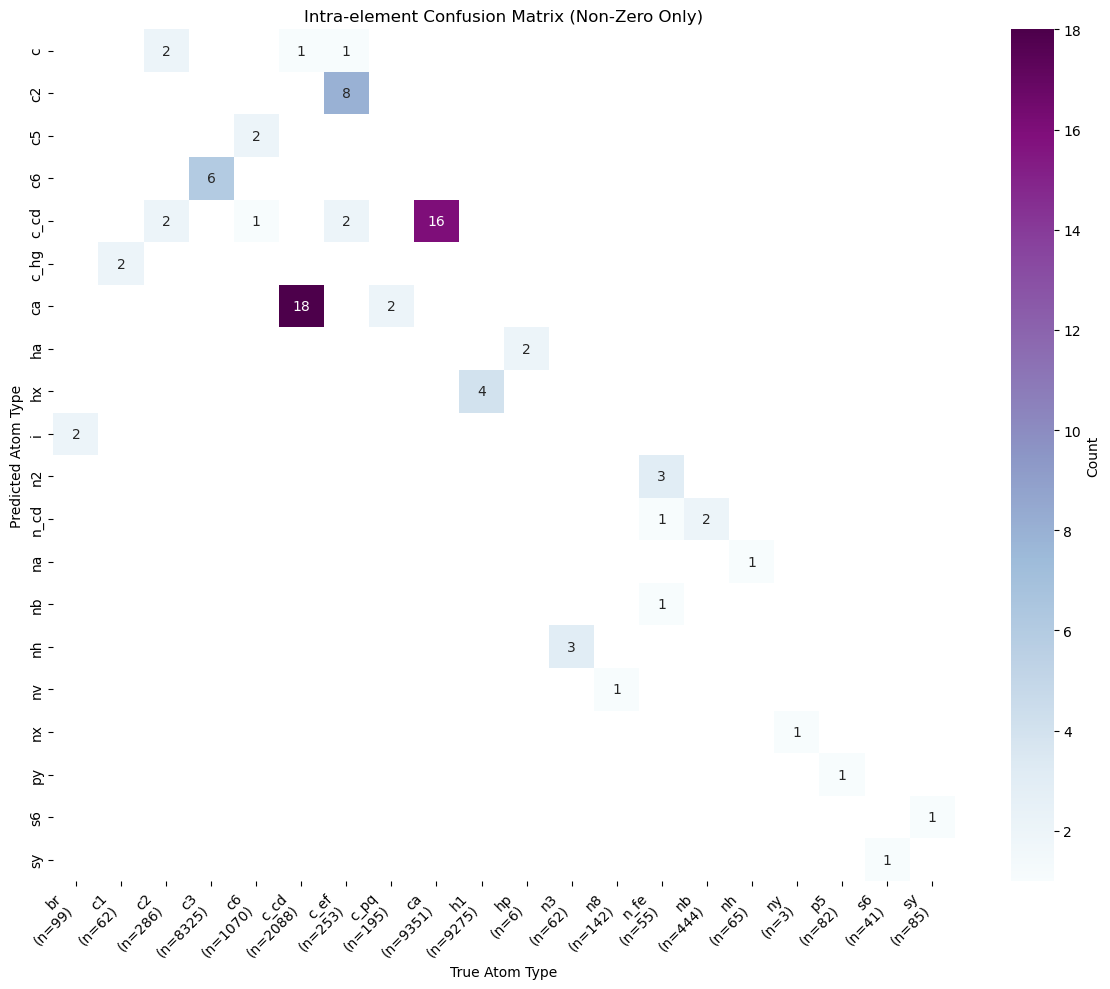

In [7]:
from atoMLtype.analysis.confusionMatrices import plot_full_confusion_matrices

plot_full_confusion_matrices(spice_record)

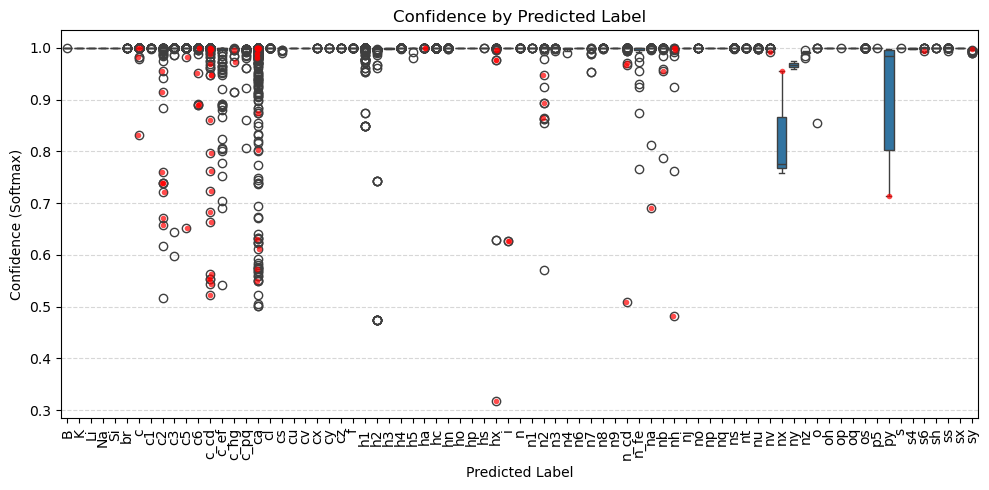

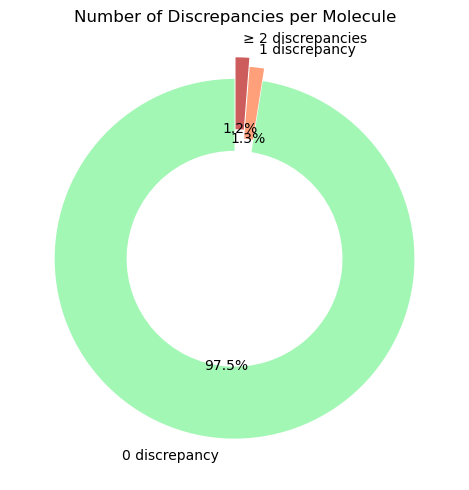

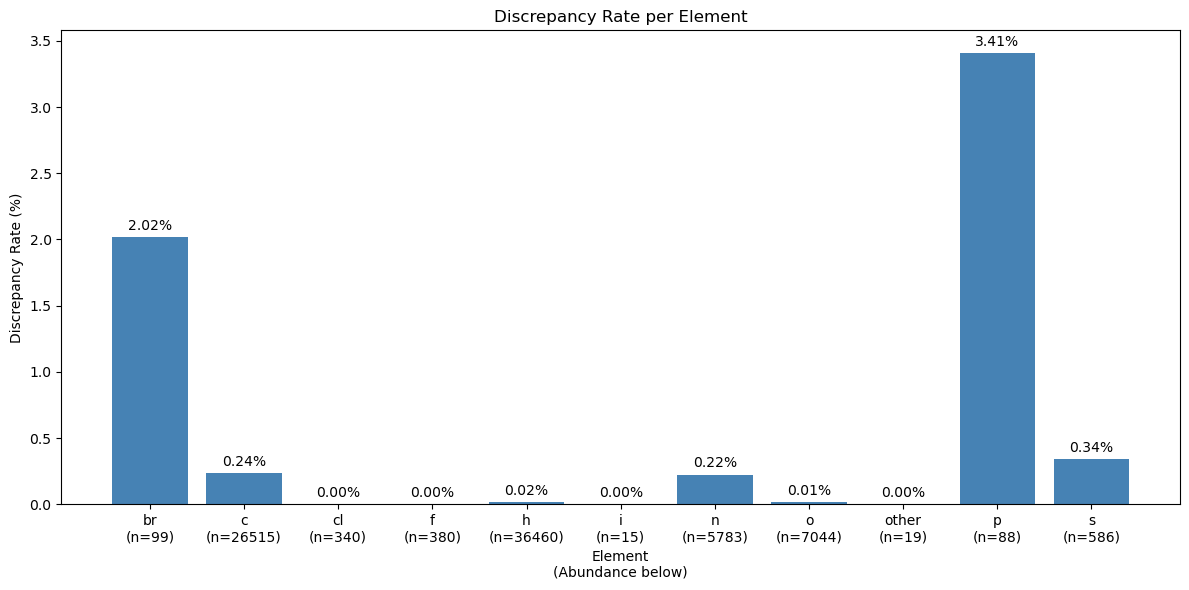

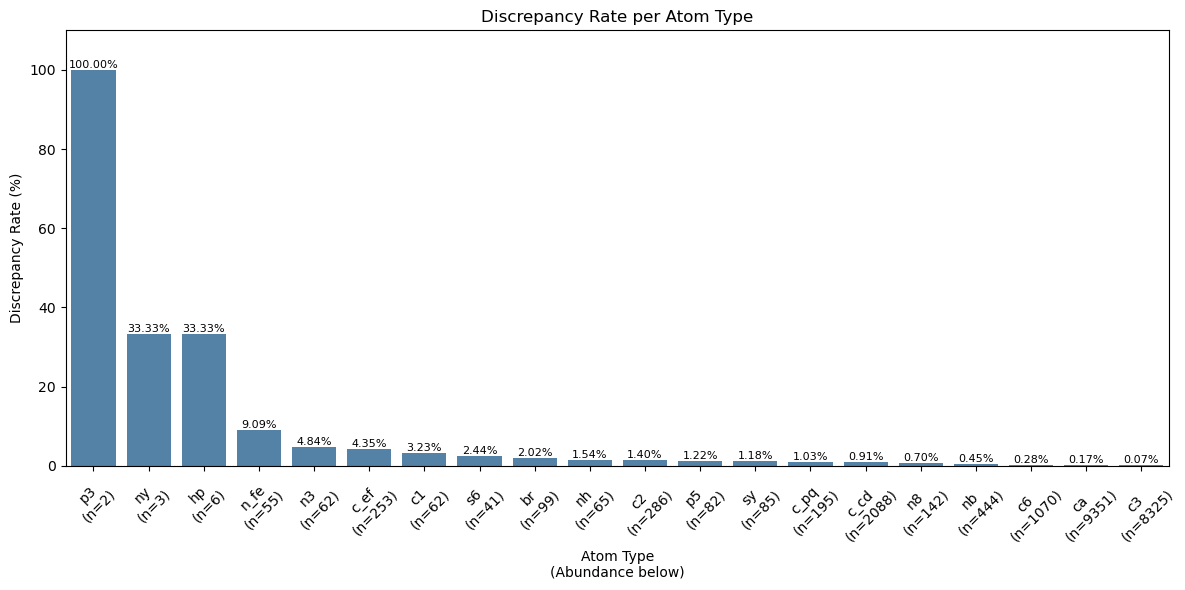

In [8]:
from atoMLtype.analysis.discrepancies import plot_confidence_by_pred_label, plot_discrepancy_distribution, plot_element_discrepancy_rate, plot_discrepancy_rate_by_atom_type


plot_confidence_by_pred_label(spice_record, 
                              sort_by='alphabetical',
                              show_mismatch=True,
                              showfliers=True, 
                              figsize=(10, 5))

plot_discrepancy_distribution(spice_record)

valid_elements = {
        "f", "cl", "br", "i", "c", "h", "n", "o", "s", "p"
    }

plot_element_discrepancy_rate(spice_record, valid_elements)

plot_discrepancy_rate_by_atom_type(spice_record)

/Users/brobello/Capstone_biovia/Biovia-1/atoMLtype/analysis/molecule_embeddings.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


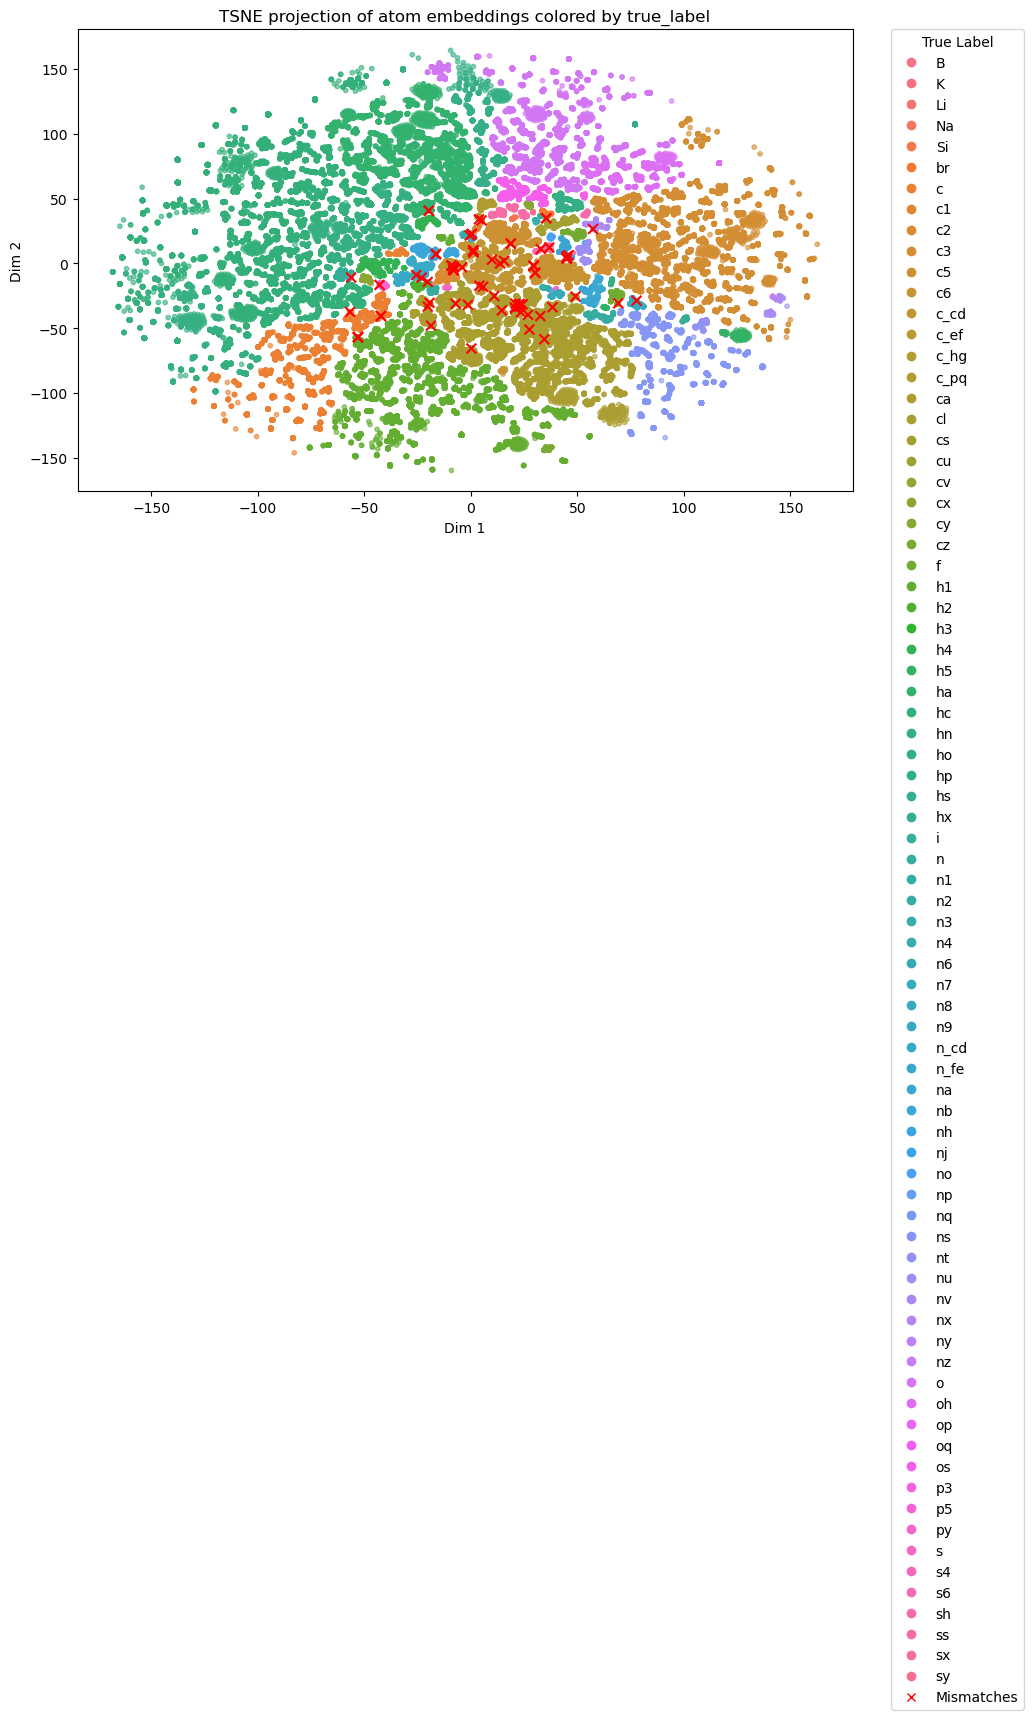

In [9]:
from atoMLtype.analysis.molecule_embeddings import visualize_prediction_embeddings

visualize_prediction_embeddings(
    pred_record=spice_record,
    key='clf_embeddings',
    method='tsne'
)

In [10]:
len(spice_record.mismatched_molecules)

39

135071031 atom 9, pred AT py for p5
135071031 atom 11, pred AT c_hg for c1


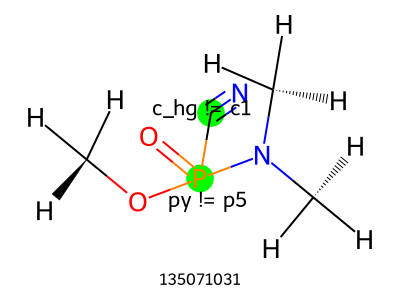

[br-] c1[nh]cc[nh+]1 atom 10, pred AT i for br


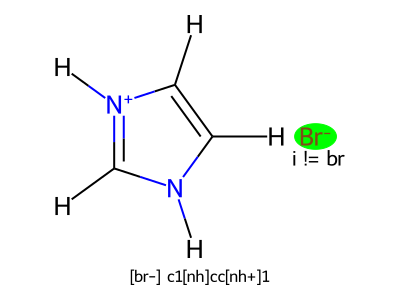

313065069 atom 29, pred AT c_cd for c2


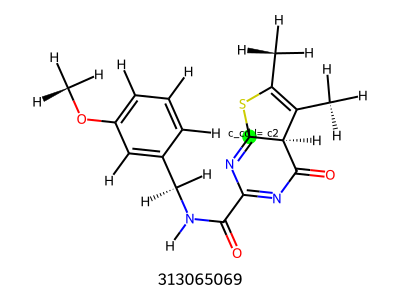

135177526 atom 2, pred AT nh for p3


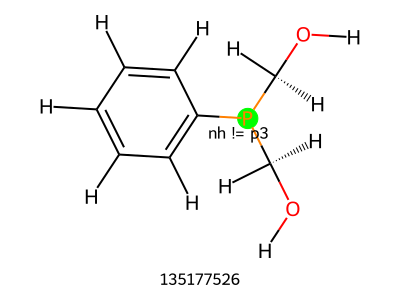

CNN GLU atom 2, pred AT nv for n8


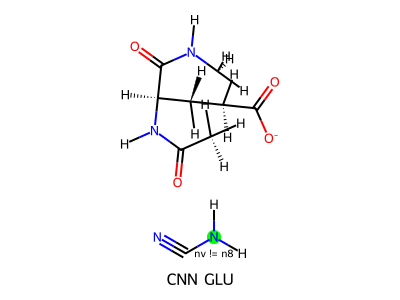

801 CYS atom 8, pred AT c_cd for ca
801 CYS atom 9, pred AT c2 for c_ef
801 CYS atom 23, pred AT n_cd for nb
801 CYS atom 24, pred AT c_cd for ca
801 CYS atom 26, pred AT c_cd for ca


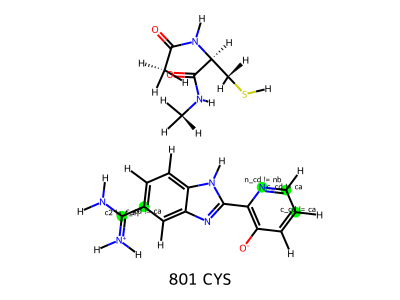

252661499 atom 14, pred AT na for nh


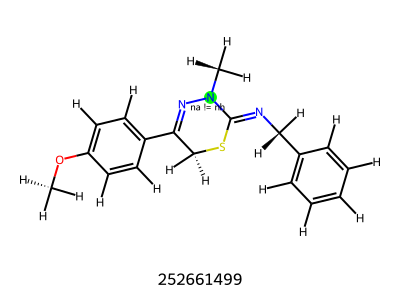

135109959 atom 14, pred AT hx for o


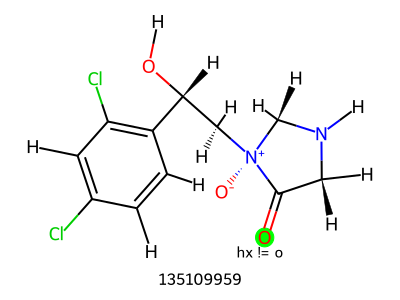

104110975 atom 24, pred AT hx for h1
104110975 atom 25, pred AT hx for h1


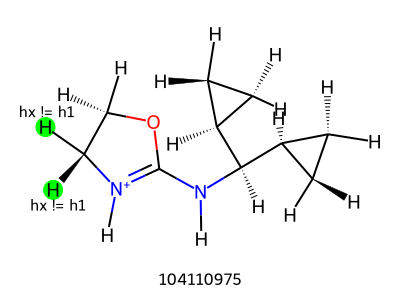

V21 VAL atom 29, pred AT sy for s6
V21 VAL atom 31, pred AT ca for c_cd
V21 VAL atom 32, pred AT ca for c_cd
V21 VAL atom 34, pred AT ca for c_cd
V21 VAL atom 36, pred AT ca for c_cd
V21 VAL atom 37, pred AT ca for c_cd
V21 VAL atom 38, pred AT ca for c_cd


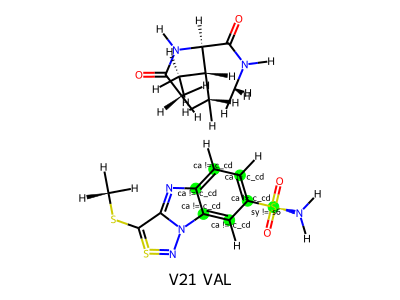

135169425 atom 3, pred AT c for c2


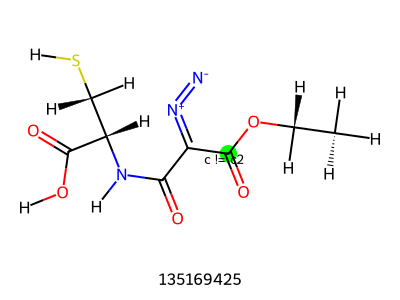

58097537 atom 26, pred AT c_cd for c6


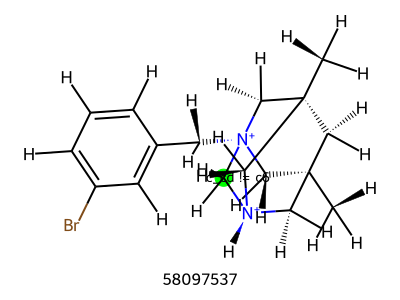

443565643 atom 9, pred AT hx for h1
443565643 atom 10, pred AT hx for h1
443565643 atom 12, pred AT c2 for c_ef


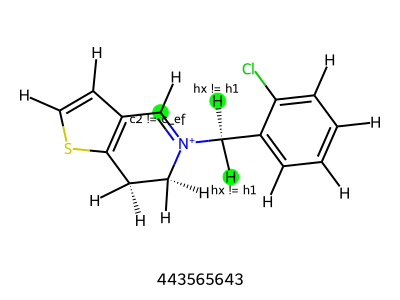

252645452 atom 1, pred AT ca for c_cd
252645452 atom 2, pred AT ca for c_cd
252645452 atom 3, pred AT ca for c_cd
252645452 atom 4, pred AT ca for c_cd
252645452 atom 5, pred AT ca for c_cd
252645452 atom 6, pred AT ca for c_cd
252645452 atom 7, pred AT c for c_ef
252645452 atom 36, pred AT n2 for n_fe


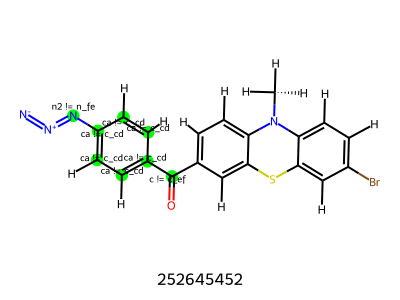

solvated 135093104 atom 1, pred AT c_hg for c1
solvated 135093104 atom 2, pred AT c2 for p3
solvated 135093104 atom 3, pred AT ha for hp
solvated 135093104 atom 4, pred AT ha for hp


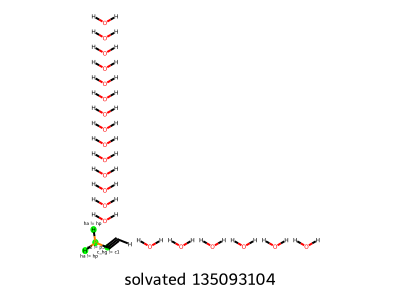

XDS ILE atom 2, pred AT n_cd for n_fe
XDS ILE atom 3, pred AT c_cd for c2


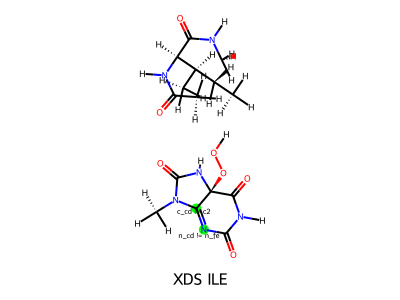

135104042 atom 12, pred AT nx for ny


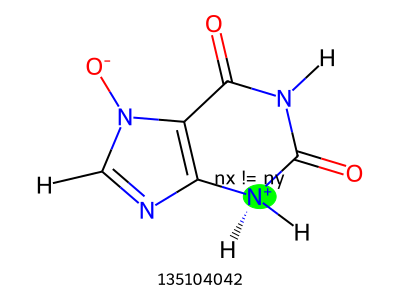

135253233 atom 21, pred AT c2 for c_ef
135253233 atom 22, pred AT c2 for c_ef


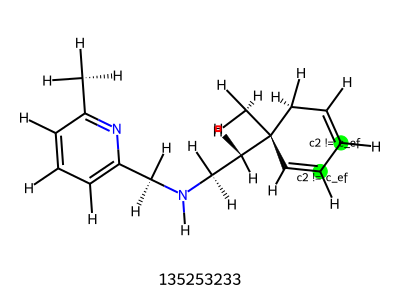

242053273 atom 8, pred AT c_cd for c_ef


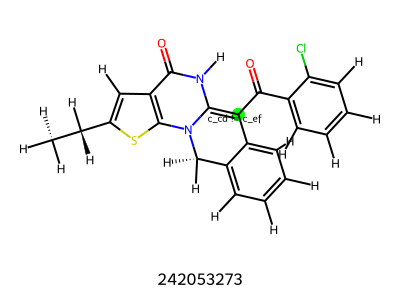

CR4 GLY atom 16, pred AT c_cd for ca
CR4 GLY atom 17, pred AT c2 for c_ef


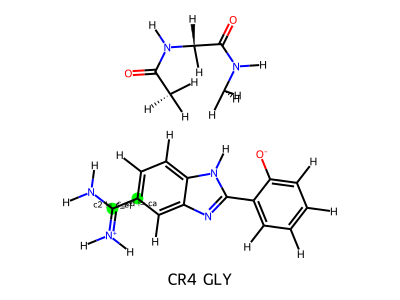

381608716 atom 16, pred AT c5 for c6
381608716 atom 37, pred AT c5 for c6


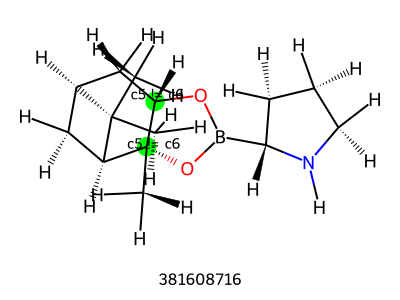

135278548 atom 10, pred AT n2 for n_fe


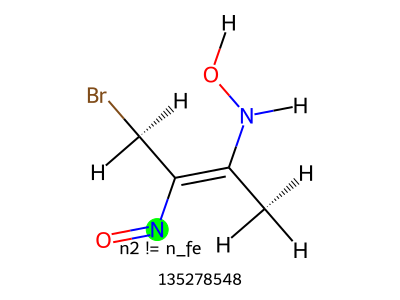

103949463 atom 16, pred AT n2 for n_fe


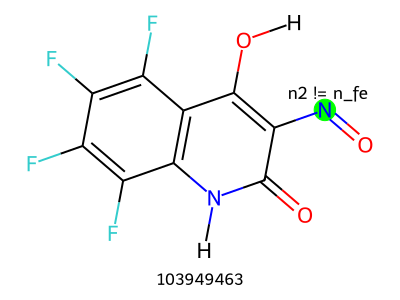

[i-:1].[br-:2] atom 0, pred AT i for br


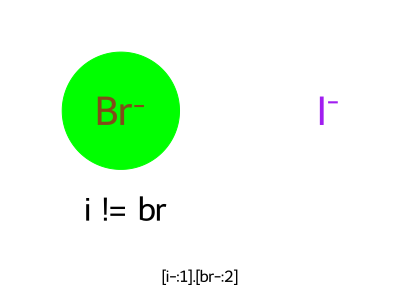

135098605 atom 13, pred AT c for c2


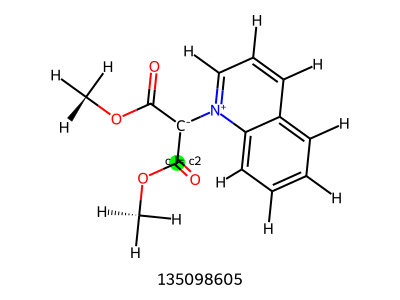

135079084 atom 4, pred AT ca for c_pq
135079084 atom 14, pred AT n_cd for nb


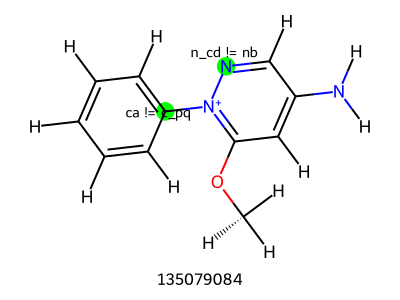

FDT GLN atom 7, pred AT c_cd for c_ef


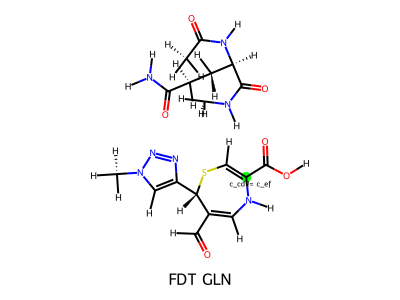

124 ALA atom 36, pred AT c_cd for ca
124 ALA atom 39, pred AT c_cd for ca
124 ALA atom 40, pred AT c2 for c_ef
124 ALA atom 49, pred AT c_cd for ca


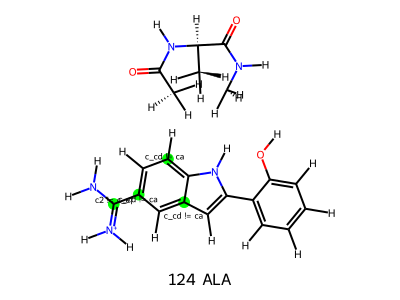

440827462 atom 13, pred AT c_cd for ca
440827462 atom 14, pred AT c_cd for ca
440827462 atom 15, pred AT c_cd for ca


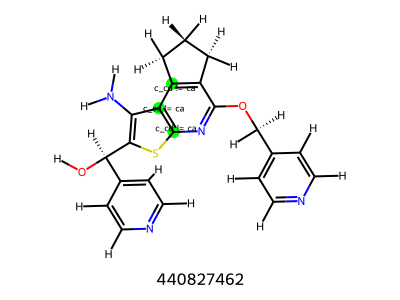

solvated 135095444 atom 1, pred AT s6 for sy


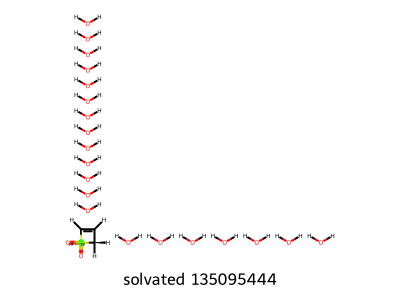

0QA LEU atom 2, pred AT nh for n3


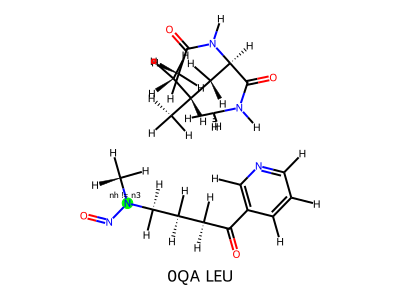

135044897 atom 9, pred AT c6 for c3
135044897 atom 12, pred AT c6 for c3
135044897 atom 15, pred AT c6 for c3
135044897 atom 26, pred AT c6 for c3
135044897 atom 29, pred AT c6 for c3
135044897 atom 32, pred AT c6 for c3


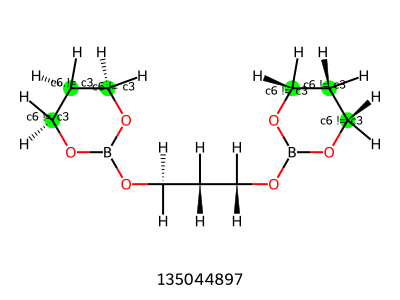

19E PHE atom 12, pred AT ca for c_pq


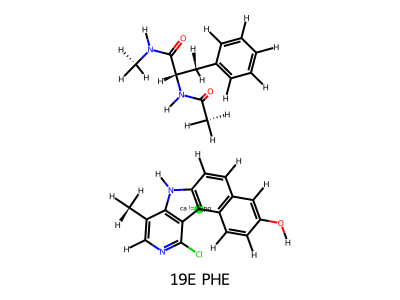

solvated 135122573 atom 7, pred AT c2 for c_ef


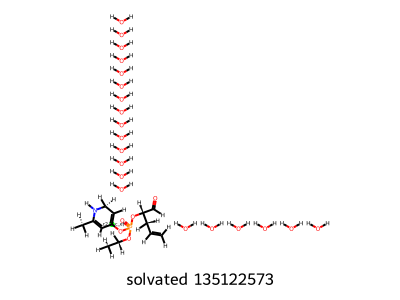

U1K ARG atom 59, pred AT c for c_cd


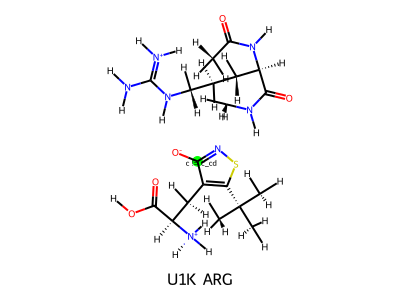

135017292 atom 2, pred AT nh for n3
135017292 atom 7, pred AT nh for n3


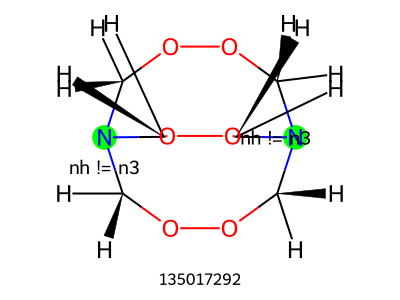

135169264 atom 5, pred AT c_cd for ca
135169264 atom 6, pred AT c_cd for ca
135169264 atom 7, pred AT c_cd for ca
135169264 atom 8, pred AT c_cd for ca


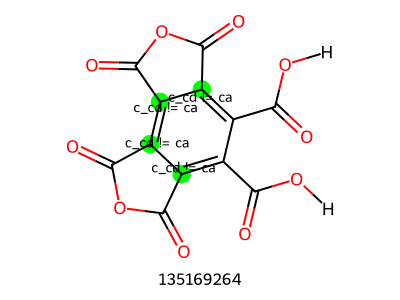

solvated 318488483 atom 0, pred AT nb for n_fe
solvated 318488483 atom 1, pred AT ca for c_cd
solvated 318488483 atom 2, pred AT ca for c_cd
solvated 318488483 atom 4, pred AT ca for c_cd
solvated 318488483 atom 8, pred AT ca for c_cd
solvated 318488483 atom 13, pred AT ca for c_cd
solvated 318488483 atom 15, pred AT ca for c_cd
solvated 318488483 atom 23, pred AT c2 for c_ef


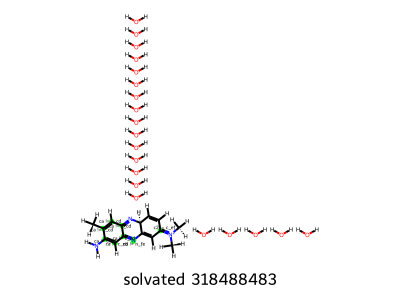

solvated 163354531 atom 15, pred AT c_cd for ca
solvated 163354531 atom 32, pred AT c_cd for ca


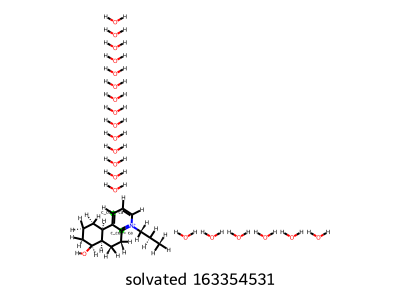

In [11]:
from atoMLtype.analysis.molecule_embeddings import draw_molecule_with_mismatches_labeled


for mol_name, atom_preds in spice_record.mismatched_molecules.items():
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol = spice_dataset.get_mol(mol_name)

    img = draw_molecule_with_mismatches_labeled(mol, atom_preds)
    display(img)  # or img.save(f"{mol_name}_mismatch.png")